<a href="https://colab.research.google.com/github/AKutergin/dsp-seminars/blob/kutergin_lab5/seminars/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay, freqz, lfilter
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для построения частотных характеристик
def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

**Скользящее среднее** – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


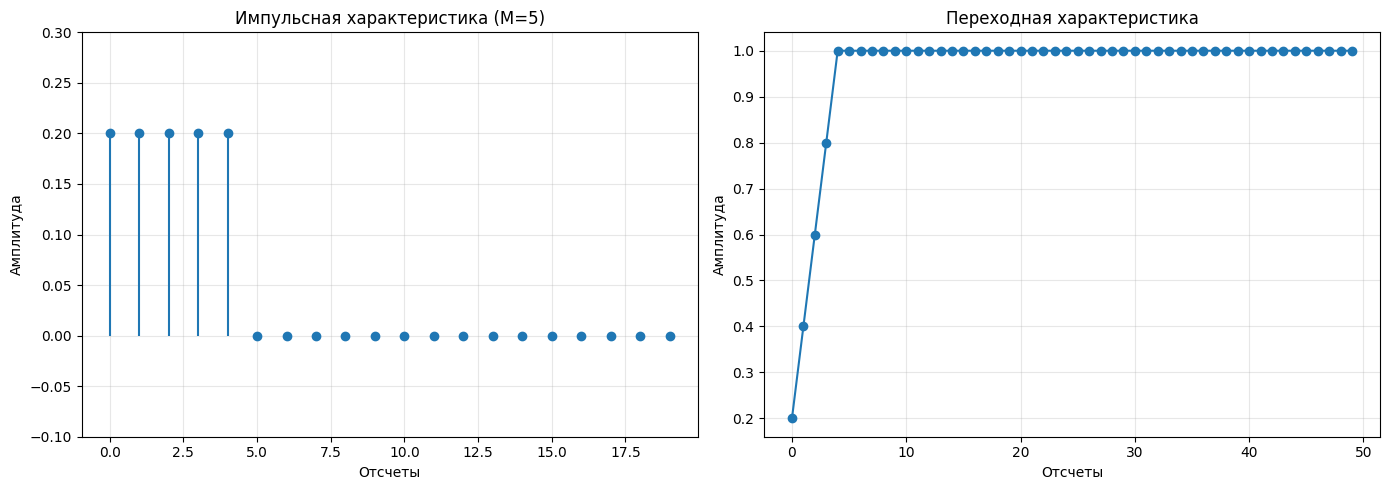

In [7]:
M = 5
b = np.ones(M) / M  # Коэффициенты b_k = 1/M
a = [1]             # Для КИХ-фильтров знаменатель всегда 1

# 2. Создаем тестовые сигналы
# Единичный импульс (delta-function)
impulse = np.zeros(20)
impulse[0] = 1

# Единичный скачок (Heaviside step)
step = np.ones(50)

# 3. Фильтрация
# Импульсная характеристика (h) — реакция на импульс
h = signal.lfilter(b, a, impulse)

# Переходная характеристика (s) — реакция на скачок
s = signal.lfilter(b, a, step)

# 4. Построение графиков
plt.figure(figsize=(14, 5))

# График импульсной характеристики
plt.subplot(1, 2, 1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (M={M})')
plt.xlabel('Отсчеты')
plt.ylabel('Амплитуда')
plt.ylim(-0.1, 0.3)
plt.grid(True, alpha=0.3)

# График переходной характеристики
plt.subplot(1, 2, 2)
plt.plot(s, 'o-')
plt.title('Переходная характеристика')
plt.xlabel('Отсчеты')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Вопрос:** Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


Фильтр хранит в памяти только последние $M$ отсчетов. Как только входной единичный импульс проходит через все $M$ ячеек памяти, он вылетает из фильтра, и на выходе снова воцаряется ноль. Переходная характеристика — это реакция фильтра на «ступеньку» (бесконечный поток единиц).


### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


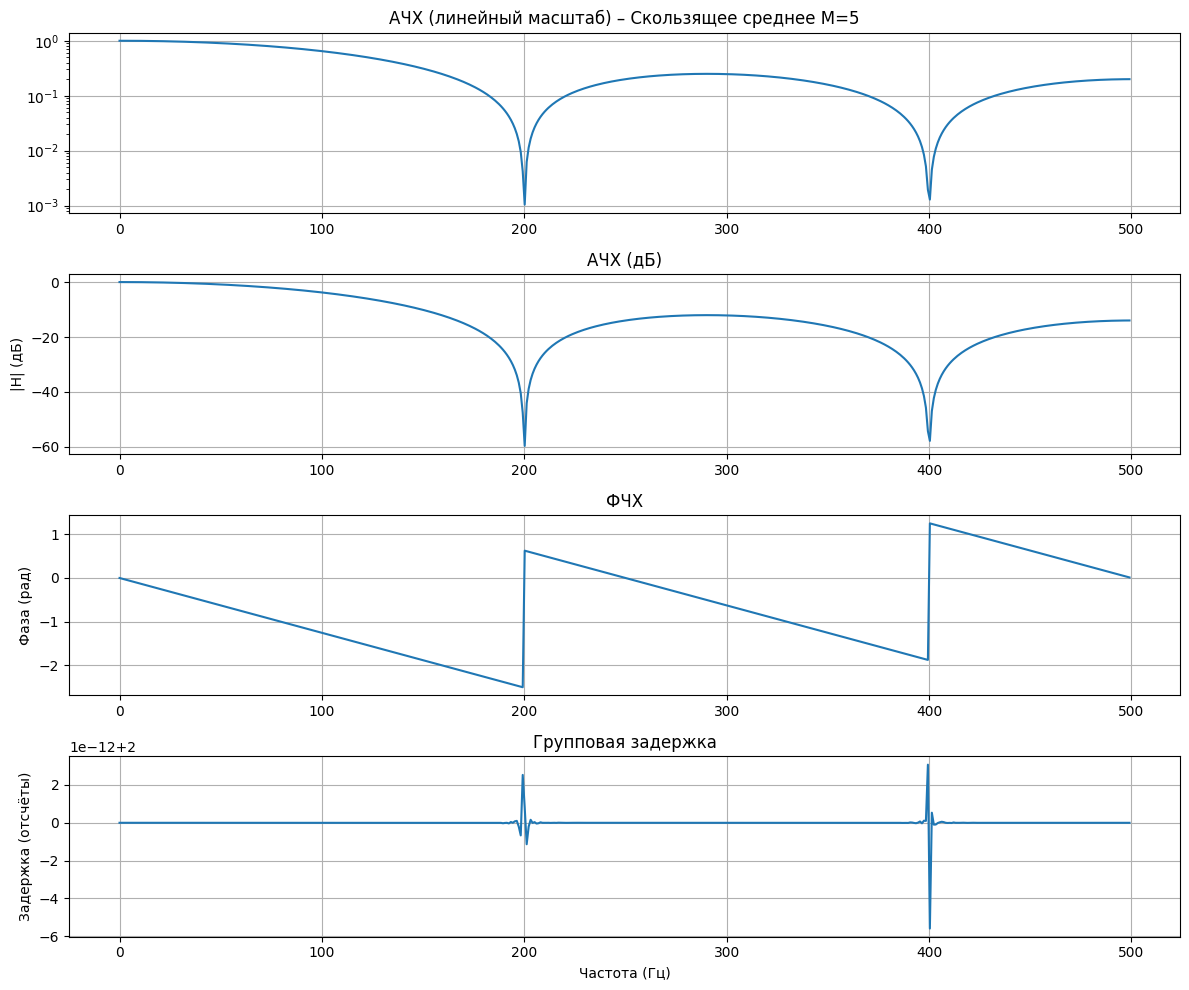

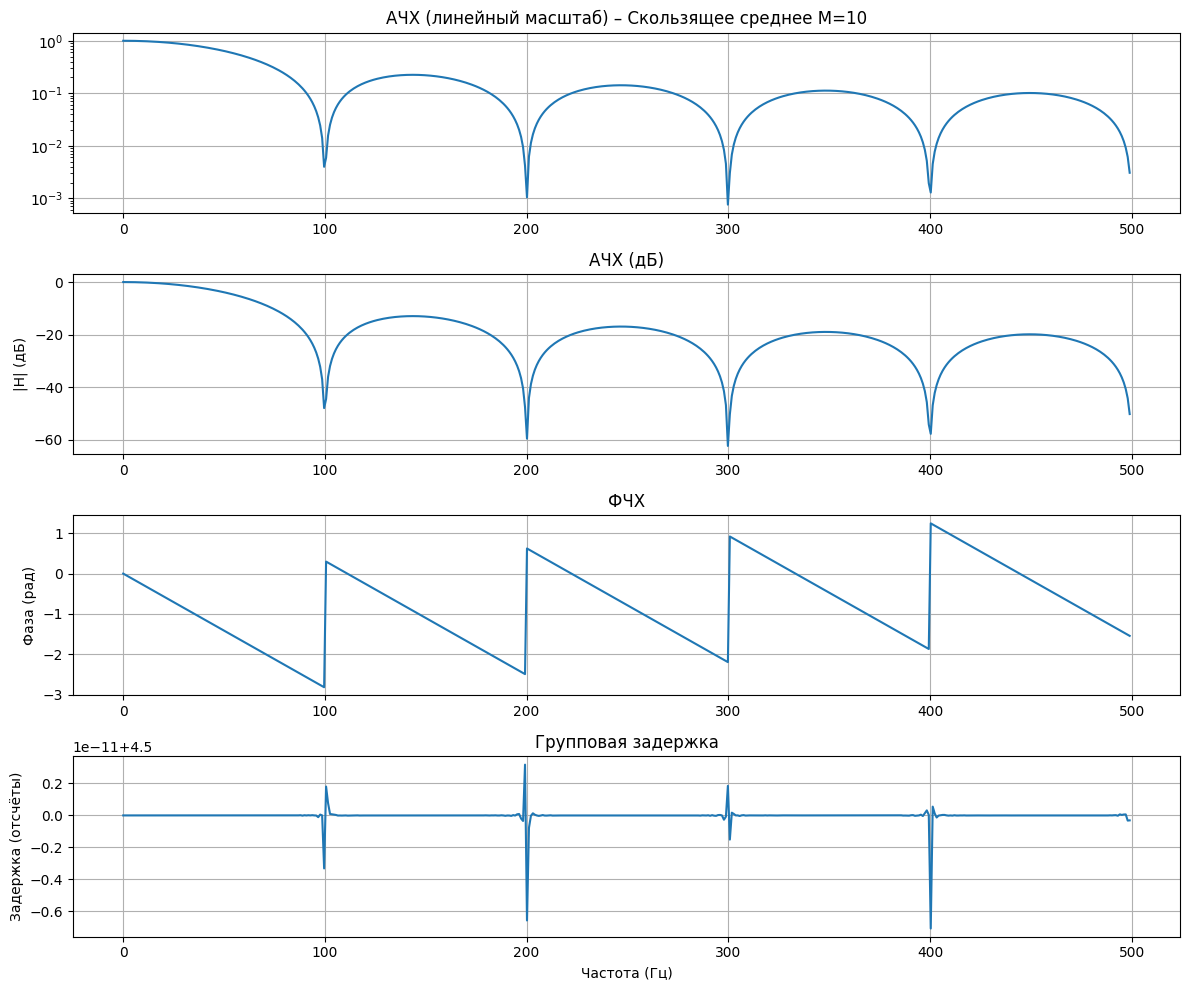

/tmp/ipykernel_1930/3306243778.py:17: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


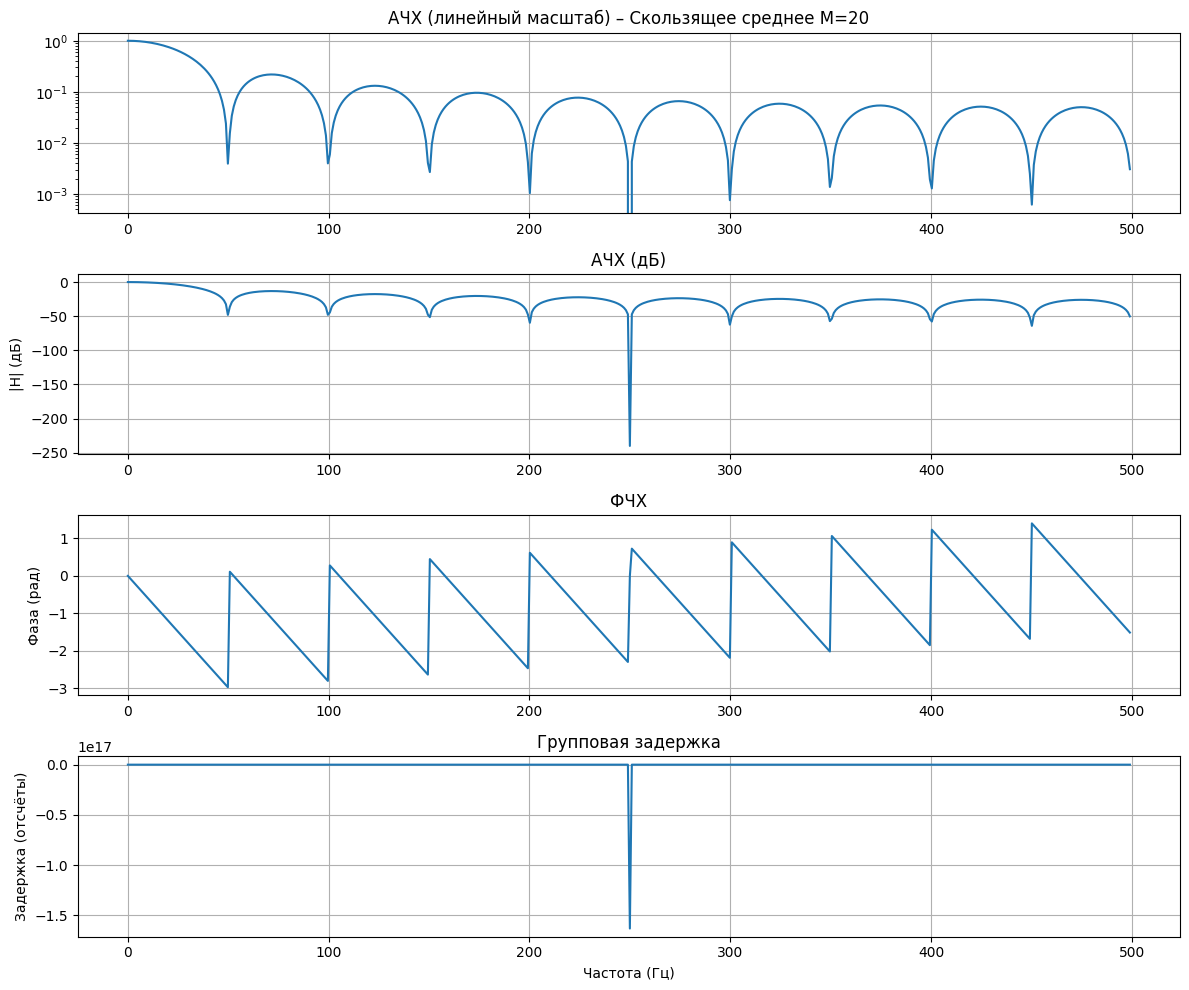

In [8]:
for M in [5, 10, 20]:
    b = np.ones(M) / M
    plot_filter_response(b, [1], fs=1000, title=f'Скользящее среднее M={M}')


**Вопрос:** Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?




*   Влияние на АЧХ: С увеличением $M$ крутизна среза растёт
*   Влияние на ФЧХ С ростом $M$ наклон ФЧХ становится круче




### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


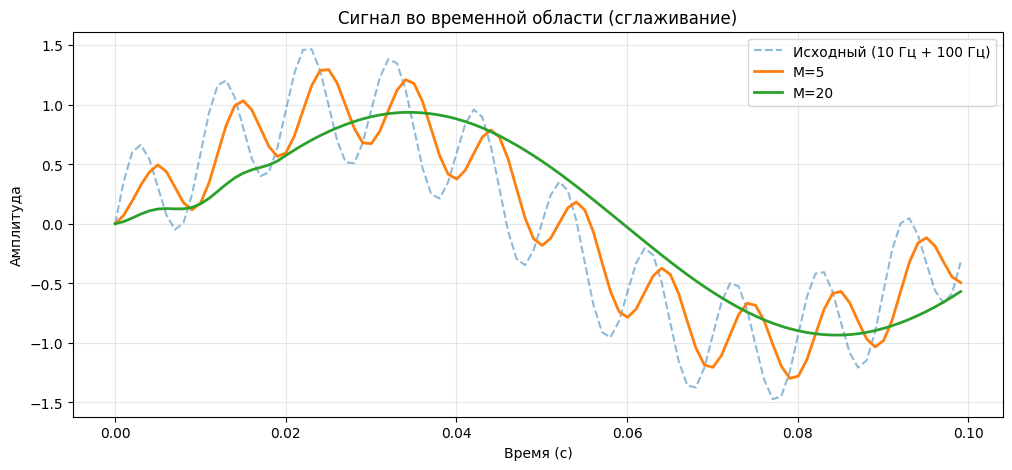

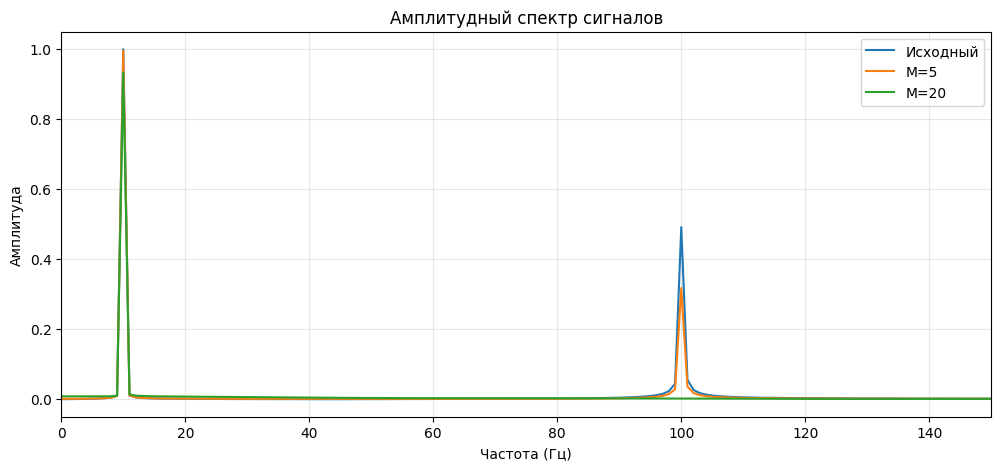

In [10]:
fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*100*t)

# Ваш код здесь: фильтрация с M=5 и M=20
b5 = np.ones(5)/5
y5 = signal.lfilter(b5, [1], x)

b20 = np.ones(20)/20
y20 = signal.lfilter(b20, [1], x)

# Временные графики (первые 100 отсчётов)
plt.figure(figsize=(12,5))
plt.plot(t[:100], x[:100], label='Исходный (10 Гц + 100 Гц)', alpha=0.5, ls='--')
plt.plot(t[:100], y5[:100], label='M=5', lw=2)
plt.plot(t[:100], y20[:100], label='M=20', lw=2)
plt.title('Сигнал во временной области (сглаживание)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Спектры
def plot_spectrum(s, label):
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(len(s), 1/fs)
    plt.plot(freq[:len(freq)//2], np.abs(X[:len(freq)//2])/(len(s)//2), label=label)

plt.figure(figsize=(12,5))
plot_spectrum(x, 'Исходный')
plot_spectrum(y5, 'M=5')
plot_spectrum(y20, 'M=20')
plt.title('Амплитудный спектр сигналов')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 150)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Вопрос:** Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


При $M=5$ (оранжевая линия): Амплитуда пика на 100 Гц заметно снизилась по сравнению с исходной (синей), но сигнал все еще присутствует на спектре. При $M=20$ (зеленая линия): Пик на 100 Гц практически исчез. Сигнал на этой частоте был подавлен почти до нуля. Это объясняется математической сутью скользящего среднего. Фильтр усредняет значения в окне длиной $M$, при $M$ = 20 в окно фильтрации попадает два полных периода синусоиды, сумма равна нулю и поэтмоу сигнал схлопывается, прим $M$ = 5 в окно попадает только половина периода, часть сигнала проходит через фильтр. Амплитудно-частотная характеристика - это инструкция, которая говорит фильтру, с каким коэффициентом пропускать каждую частоту.


## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


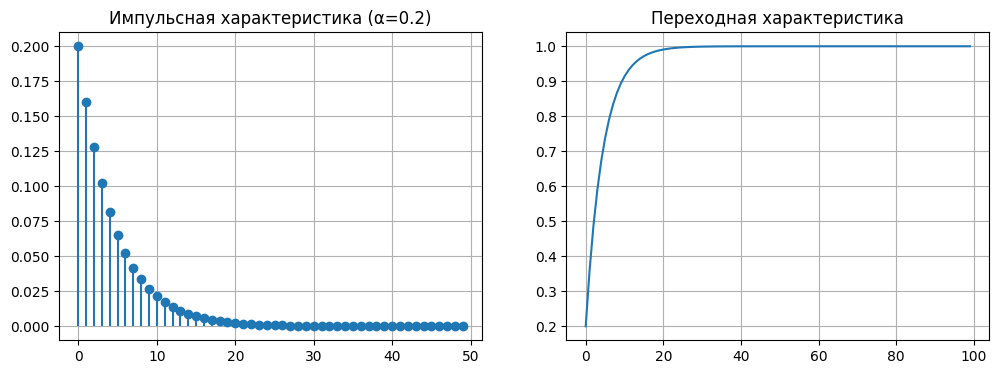

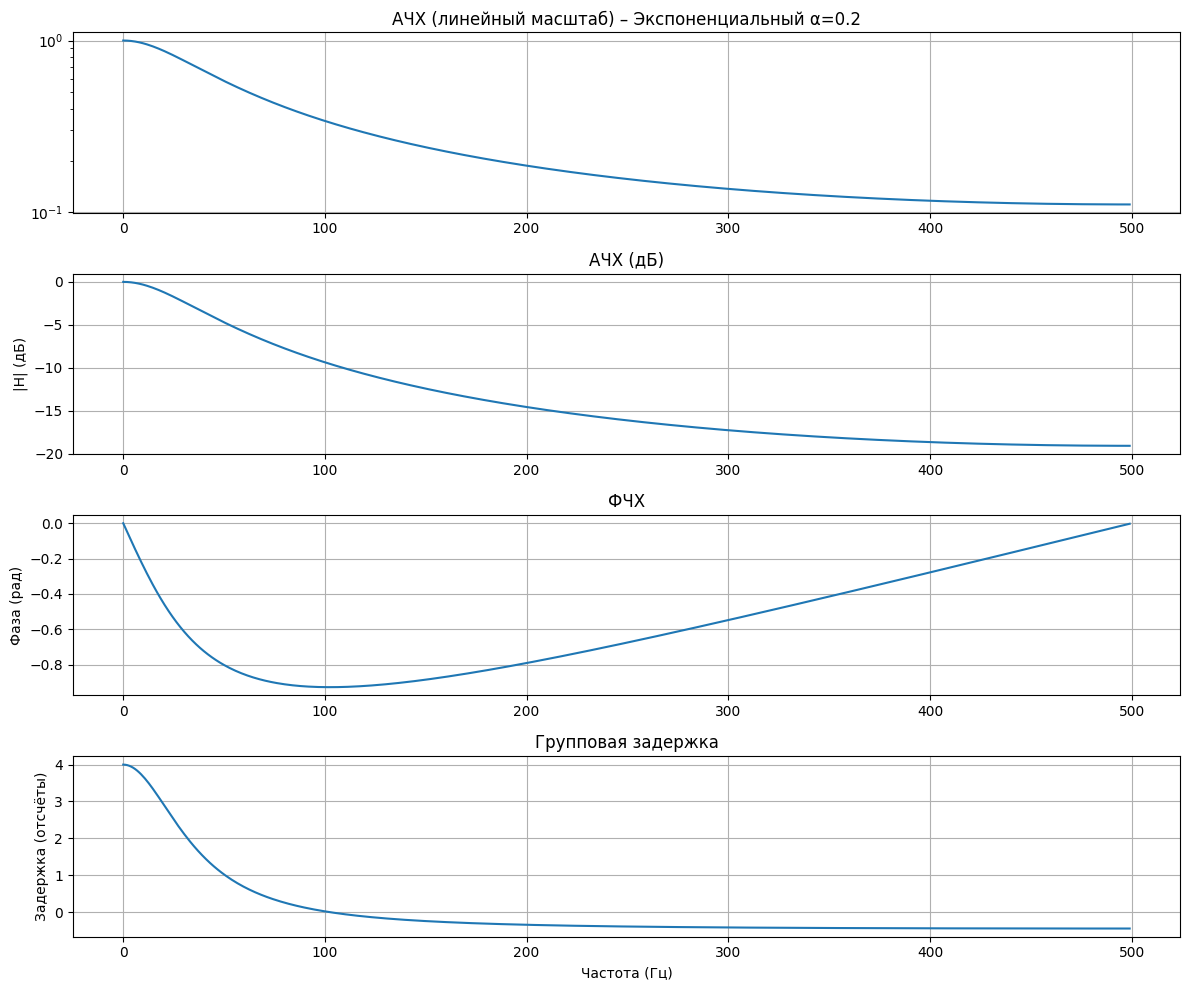

In [11]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

# Импульсная характеристика (длина 50)
impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)
# Переходная характеристика (длина 100)
step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

# Частотные характеристики
plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')


### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


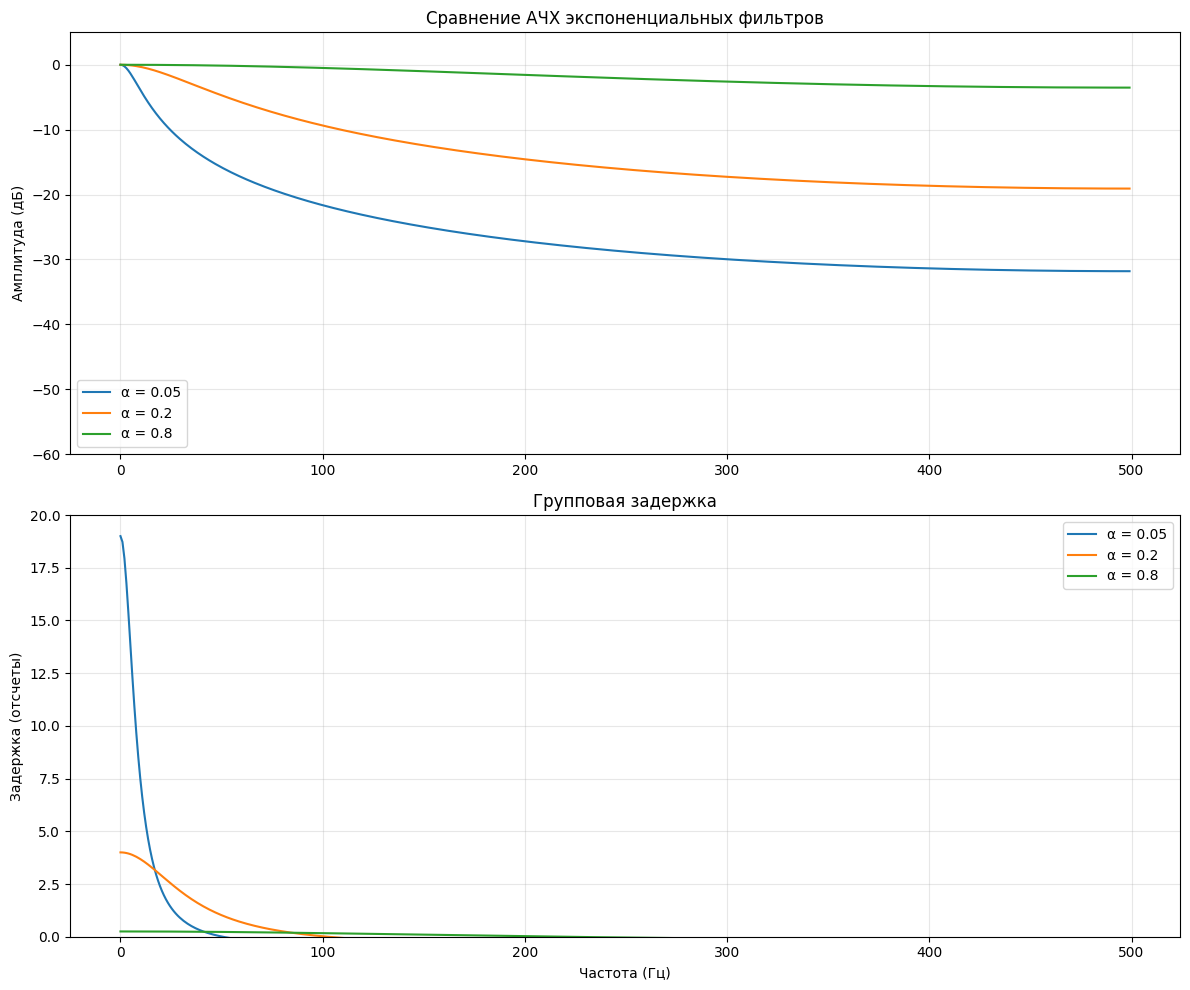

In [12]:
alphas = [0.05, 0.2, 0.8]
# Ваш код здесь: построить АЧХ (в дБ) и групповую задержку для всех α
plt.figure(figsize=(12, 10))
for alpha in alphas:
    b = [alpha]
    a = [1, -(1 - alpha)]

    # Расчет АЧХ
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20 * np.log10(np.abs(H) + 1e-12)

    # Расчет групповой задержки
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    # Построение АЧХ
    plt.subplot(2, 1, 1)
    plt.plot(w, mag_dB, label=f'α = {alpha}')

    # Построение групповой задержки
    plt.subplot(2, 1, 2)
    plt.plot(w_gd, gd, label=f'α = {alpha}')

# Оформление АЧХ
plt.subplot(2, 1, 1)
plt.title('Сравнение АЧХ экспоненциальных фильтров')
plt.ylabel('Амплитуда (дБ)')
plt.ylim(-60, 5)
plt.grid(True, which="both", alpha=0.3)
plt.legend()

# Оформление задержки
plt.subplot(2, 1, 2)
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчеты)')
plt.ylim(0, 20)
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


**Вопрос:** Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


С увеличением α увеличивается скорость реакции и делает АЧХ практически плоской


### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


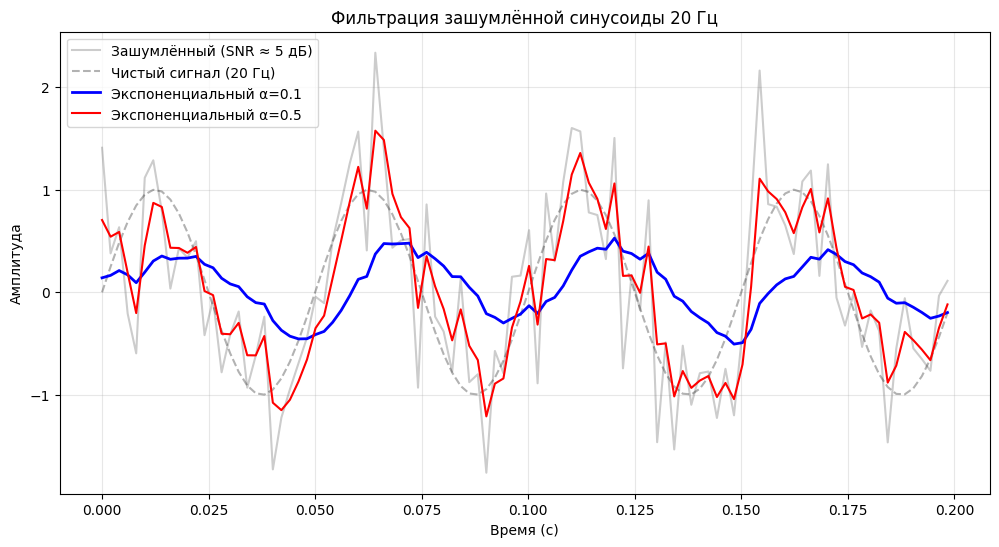

In [14]:
fs = 500
t = np.linspace(0, 1, fs)
x_clean = np.sin(2*np.pi*20*t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

# Ваш код здесь: фильтрация с alpha=0.1 и alpha=0.5
alpha1 = 0.1
alpha2 = 0.5
b1, a1 = [alpha1], [1, -(1 - alpha1)]
b2, a2 = [alpha2], [1, -(1 - alpha2)]
y_01 = signal.lfilter(b1, a1, x_noisy)
y_05 = signal.lfilter(b2, a2, x_noisy)

plt.figure(figsize=(12, 6))
plt.plot(t[:100], x_noisy[:100], color='gray', alpha=0.4, label='Зашумлённый (SNR ≈ 5 дБ)')
plt.plot(t[:100], x_clean[:100], 'k--', alpha=0.3, label='Чистый сигнал (20 Гц)')
plt.plot(t[:100], y_01[:100], color='blue', lw=2, label=f'Экспоненциальный α={alpha1}')
plt.plot(t[:100], y_05[:100], color='red', lw=1.5, label=f'Экспоненциальный α={alpha2}')

plt.title('Фильтрация зашумлённой синусоиды 20 Гц')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Вопрос:** Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


На временном графике фильтрации групповая задержка проявляется как временной сдвиг пиков отфильтрованного сигнала относительно исходного чистого сигнала


## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


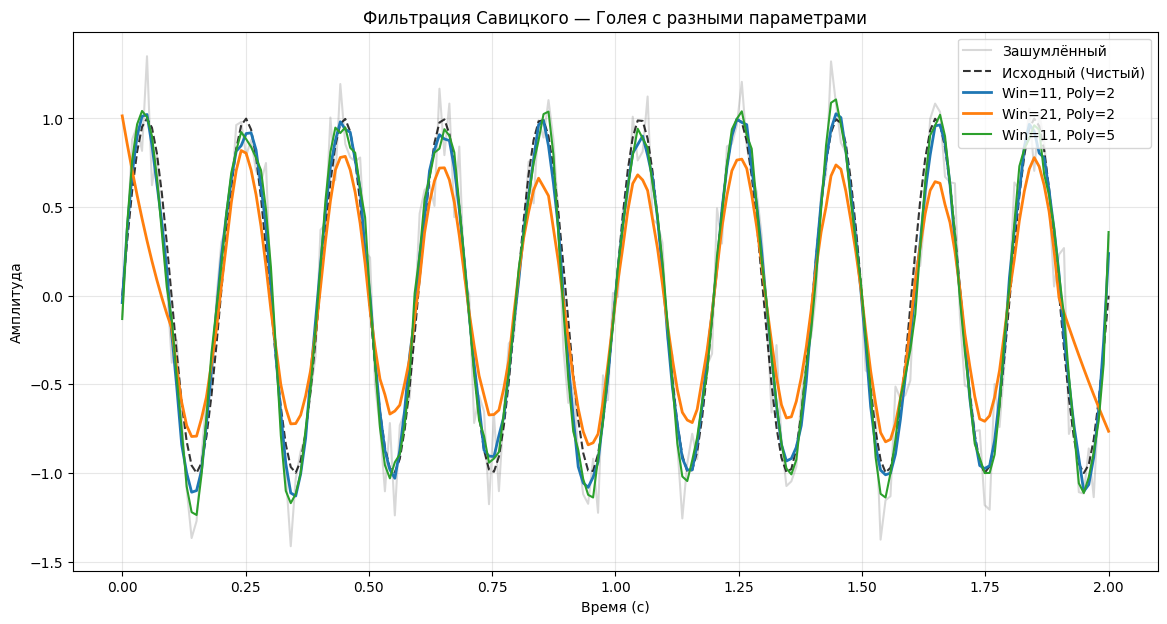

In [15]:
fs = 100
t = np.linspace(0, 2, 2*fs)
x_clean = np.sin(2*np.pi*5*t)
noise = 0.2 * np.random.randn(len(t))
x_noisy = x_clean + noise

# Ваш код здесь: применить savgol_filter с разными параметрами
y1 = savgol_filter(x_noisy, window_length=11, polyorder=2)
y2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
y3 = savgol_filter(x_noisy, window_length=11, polyorder=5)

plt.figure(figsize=(14, 7))
plt.plot(t, x_noisy, color='gray', alpha=0.3, label='Зашумлённый')
plt.plot(t, x_clean, 'k--', alpha=0.8, label='Исходный (Чистый)')

plt.plot(t, y1, label='Win=11, Poly=2', lw=2)
plt.plot(t, y2, label='Win=21, Poly=2', lw=2)
plt.plot(t, y3, label='Win=11, Poly=5', lw=1.5)

plt.title('Фильтрация Савицкого — Голея с разными параметрами')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Вопрос 3.1:** Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


Увеличение длины окна приводит к значительному росту степени сглаживания и к ухудшению сохранения формы. Увеличение порядка полинома дает противоположный результат


### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


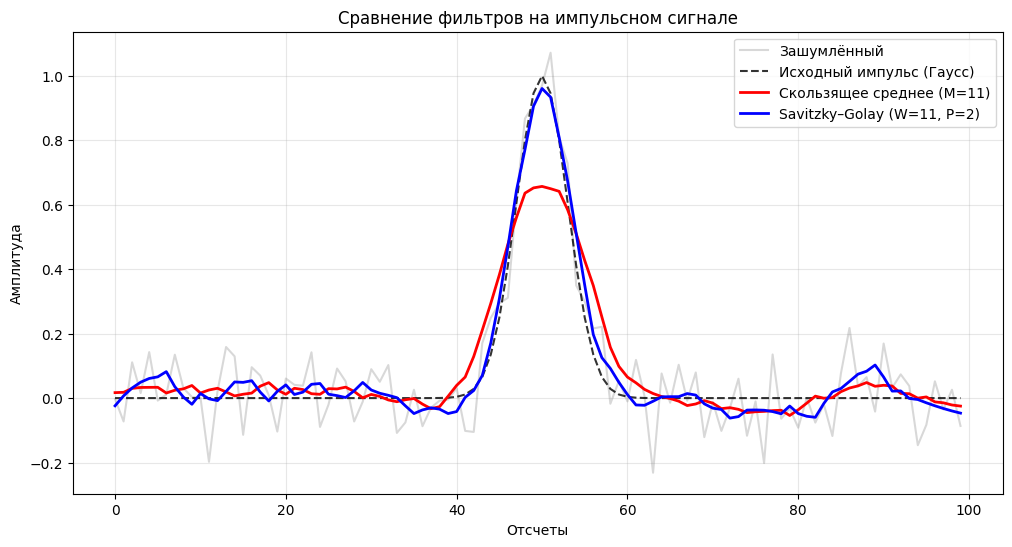

In [16]:
# Генерация гауссова импульса
N = 100
x_pulse = np.zeros(N)
x_pulse[N//2] = 1
sigma = 3
gaussian = np.exp(-(np.arange(N)-N//2)**2/(2*sigma**2))
x_clean_pulse = gaussian / np.max(gaussian)
noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

# Ваш код здесь: фильтрация (скользящее среднее и savgol)
window_len = 11
b_ma = np.ones(window_len) / window_len
y_ma = np.convolve(x_noisy_pulse, b_ma, mode='same')
y_sg = savgol_filter(x_noisy_pulse, window_length=11, polyorder=2)

plt.figure(figsize=(12, 6))
plt.plot(x_noisy_pulse, color='gray', alpha=0.3, label='Зашумлённый')
plt.plot(x_clean_pulse, 'k--', alpha=0.8, label='Исходный импульс (Гаусс)')

plt.plot(y_ma, color='red', lw=2, label='Скользящее среднее (M=11)')
plt.plot(y_sg, color='blue', lw=2, label='Savitzky–Golay (W=11, P=2)')

plt.title('Сравнение фильтров на импульсном сигнале')
plt.xlabel('Отсчеты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Вопрос:** Какой из фильтров лучше сохраняет пик?


**Ответ:** Лучше всего сохраняет пик фильтр Савицкого — Голея


### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


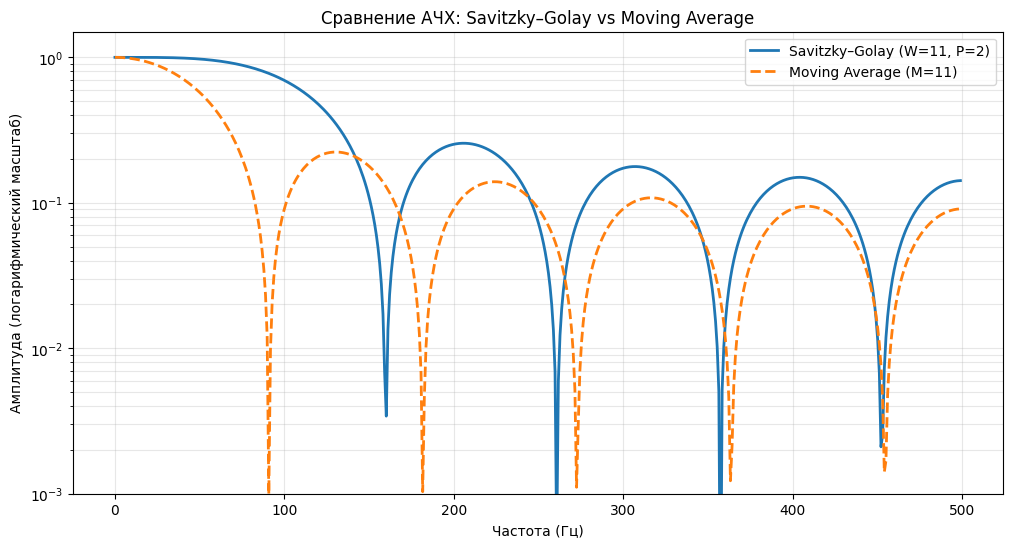

In [19]:
window_length = 11
polyorder = 2
coeffs = savgol_coeffs(window_length, polyorder)
coeffs = coeffs / np.sum(coeffs)   # нормировка

# Ваш код здесь: вычислить АЧХ через freqz для coeffs и для скользящего среднего
coeffs_sg = savgol_coeffs(window_length, polyorder)
coeffs_sg = coeffs_sg / np.sum(coeffs_sg)
coeffs_ma = np.ones(window_length) / window_length
w_sg, h_sg = freqz(coeffs_sg, [1], fs=1000)
w_ma, h_ma = freqz(coeffs_ma, [1], fs=1000)

#  Построение
plt.figure(figsize=(12, 6))
plt.semilogy(w_sg, np.abs(h_sg), label=f'Savitzky–Golay (W={window_length}, P={polyorder})', lw=2)
plt.semilogy(w_ma, np.abs(h_ma), label=f'Moving Average (M={window_length})', lw=2, linestyle='--')

plt.title('Сравнение АЧХ: Savitzky–Golay vs Moving Average')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (логарифмический масштаб)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.ylim(1e-3, 1.5)
plt.show()

# Построить на одном графике (логарифмический масштаб)


**Вопрос:** Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?


Отличия АЧХ в ширине полосы пропускания,у скользящего среднего спад начинается почти сразу, а также пропускает низкие частоты. Поскольку АЧХ фильтра Савицкого — Голея шире и «плотнее» на низких частотах, он пропускает основные гармоники, формирующие пик, почти без изменений амплитуды. Скользящее среднее начинает подавлять эти частоты слишком рано


### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


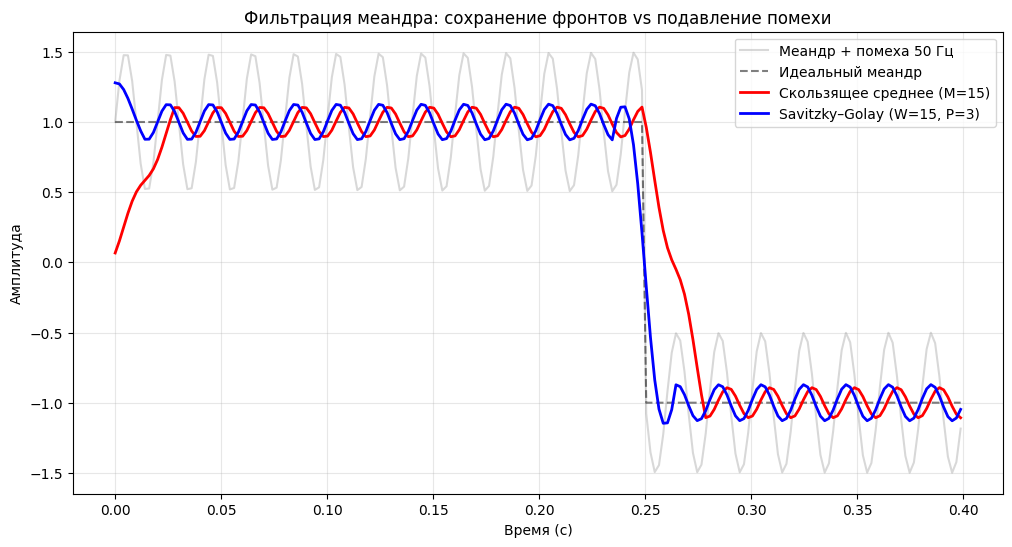

In [20]:
fs = 500
t = np.linspace(0, 1, fs)
meander = signal.square(2*np.pi*2*t)
interference = 0.5 * np.sin(2*np.pi*50*t)
x_meander = meander + interference

# Ваш код здесь: фильтрация
y_sg = savgol_filter(x_meander, window_length=15, polyorder=3)
window_ma = 15
b_ma = np.ones(window_ma) / window_ma
y_ma = signal.lfilter(b_ma, [1], x_meander)

plt.figure(figsize=(12, 6))
plt.plot(t[:200], x_meander[:200], color='gray', alpha=0.3, label='Меандр + помеха 50 Гц')
plt.plot(t[:200], meander[:200], 'k--', alpha=0.5, label='Идеальный меандр')

plt.plot(t[:200], y_ma[:200], color='red', lw=2, label=f'Скользящее среднее (M={window_ma})')
plt.plot(t[:200], y_sg[:200], color='blue', lw=2, label='Savitzky–Golay (W=15, P=3)')

plt.title('Фильтрация меандра: сохранение фронтов vs подавление помехи')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Вопрос:** Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


учше всего подходит фильтр Савицкого — Голея, потому что сохраняется крутизна фронта, минимально искажается форма и отсутствие фазового сдвига


## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


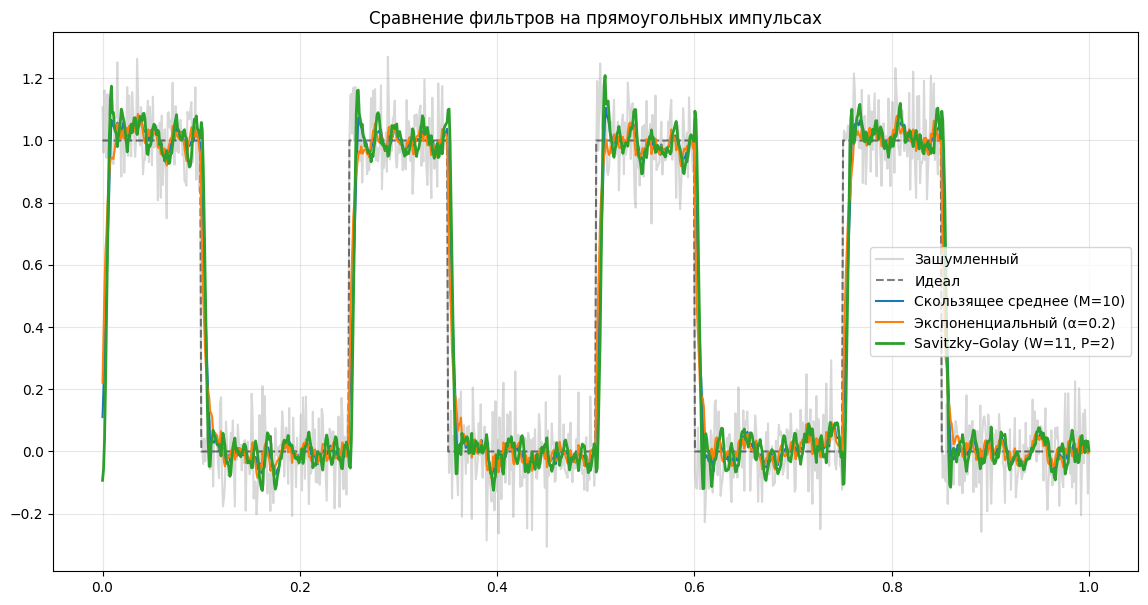

In [24]:
# Сигнал с прямоугольными импульсами
fs = 1000
t = np.linspace(0, 1, fs)
pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1
noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

# 1. Скользящее среднее (M=10)
b_ma = np.ones(10) / 10
a_ma = [1]

# 2. Экспоненциальный БИХ (alpha=0.2)
b_exp = [0.2]
a_exp = [1, -0.8]

# 3. Savitzky–Golay (W=11, P=2)
b_sg = savgol_coeffs(11, 2)
b_sg /= np.sum(b_sg) # Нормировка для АЧХ
a_sg = [1]

# Фильтрация импульсного поезда
y_ma = lfilter(b_ma, a_ma, x_pulse_noisy)
y_exp = lfilter(b_exp, a_exp, x_pulse_noisy)
y_sg = lfilter(b_sg, a_sg, x_pulse_noisy) # Здесь lfilter имитирует КИХ-режим

imp = np.zeros(50); imp[0] = 1
step = np.ones(50)

# Реакции
h_ma = lfilter(b_ma, a_ma, imp)
h_exp = lfilter(b_exp, a_exp, imp)
h_sg = lfilter(b_sg, a_sg, imp)

s_ma = lfilter(b_ma, a_ma, step)
s_exp = lfilter(b_exp, a_exp, step)
s_sg = lfilter(b_sg, a_sg, step)

plt.figure(figsize=(14, 7))
plt.plot(t, x_pulse_noisy, color='gray', alpha=0.3, label='Зашумленный')
plt.plot(t, pulse_train, 'k--', alpha=0.5, label='Идеал')

plt.plot(t, y_ma, label='Скользящее среднее (M=10)', lw=1.5)
plt.plot(t, y_exp, label='Экспоненциальный (α=0.2)', lw=1.5)
plt.plot(t, y_sg, label='Savitzky–Golay (W=11, P=2)', lw=2)

plt.title('Сравнение фильтров на прямоугольных импульсах')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Вопрос:** Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


Наилучшее подваление шума у скользящего среднего, лучше сохраняются фронты у Савицкого-Голея, наименьшее фазовые искажения у Савицкого-Голея
